In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import pickle
import json

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Load data
df = pd.read_csv("../data/processed/features_toba.csv", parse_dates=["date"])
balige = df[df["location"] == "Balige (Tobasa)"].copy()
balige = balige.sort_values("date").reset_index(drop=True)

series = balige["temperature_2m_max"].values
dates  = balige["date"].values

print(f"Data loaded: {len(series)} hari")
print(f"TensorFlow version: {tf.__version__}")

Data loaded: 3624 hari
TensorFlow version: 2.21.0


In [2]:
# LSTM butuh data dinormalisasi ke range 0-1
scaler = MinMaxScaler(feature_range=(0, 1))
series_scaled = scaler.fit_transform(series.reshape(-1, 1)).flatten()

# Fungsi buat sequence input-output untuk LSTM
# Contoh window=14: input hari 1-14, output hari 15
def create_sequences(data, window_size=14):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

WINDOW_SIZE = 14  # Pakai 14 hari terakhir untuk prediksi hari berikutnya

X, y = create_sequences(series_scaled, WINDOW_SIZE)

# Reshape X untuk LSTM: (samples, timesteps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

print(f"Window size : {WINDOW_SIZE} hari")
print(f"X shape     : {X.shape}   (samples, timesteps, features)")
print(f"y shape     : {y.shape}   (samples,)")

Window size : 14 hari
X shape     : (3610, 14, 1)   (samples, timesteps, features)
y shape     : (3610,)   (samples,)


Train: 2888 sequences
Test : 722 sequences


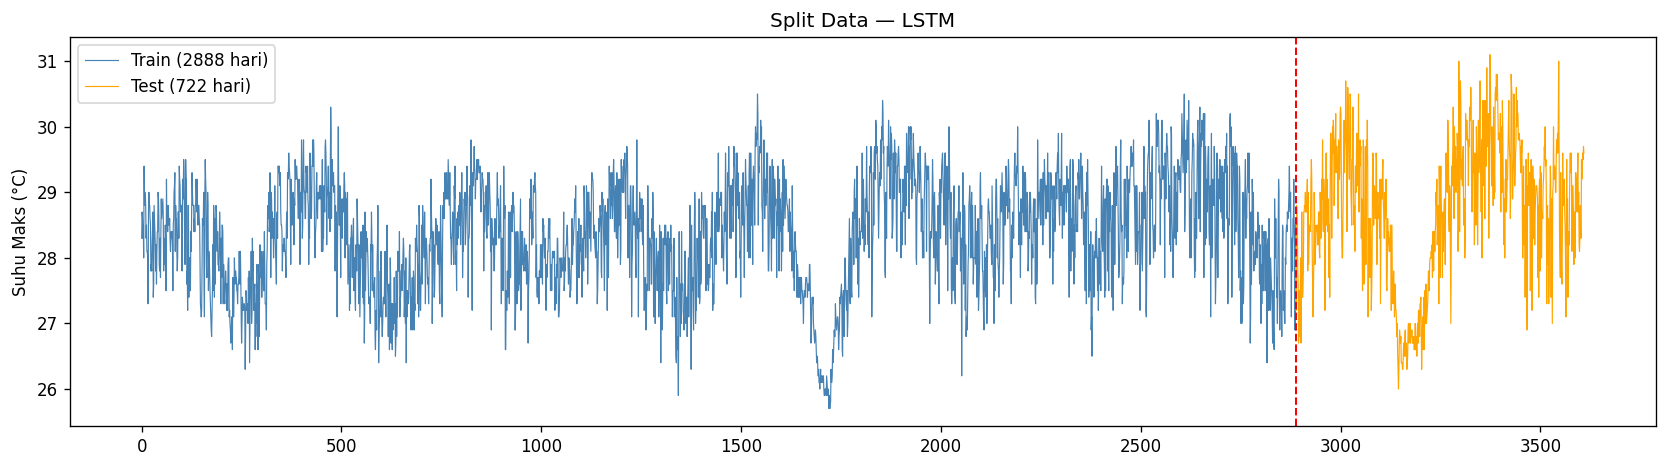

In [3]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Dates untuk test set (offset window_size)
test_dates = dates[WINDOW_SIZE + split_idx:]

print(f"Train: {len(X_train)} sequences")
print(f"Test : {len(X_test)} sequences")

# Visualisasi split
train_actual = scaler.inverse_transform(y_train.reshape(-1,1)).flatten()
test_actual  = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(range(len(train_actual)), train_actual,
        color="steelblue", linewidth=0.7, label=f"Train ({len(train_actual)} hari)")
ax.plot(range(len(train_actual), len(train_actual)+len(test_actual)),
        test_actual, color="orange", linewidth=0.7, label=f"Test ({len(test_actual)} hari)")
ax.axvline(len(train_actual), color="red", linestyle="--", linewidth=1.2)
ax.set_title("Split Data — LSTM")
ax.set_ylabel("Suhu Maks (°C)")
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
model = Sequential([
    # Layer LSTM pertama — tangkap pola jangka panjang
    LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
    Dropout(0.2),

    # Layer LSTM kedua — refine pola
    LSTM(32, return_sequences=False),
    Dropout(0.2),

    # Output layer — prediksi 1 nilai (suhu besok)
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,          # Stop kalau 15 epoch tidak ada peningkatan
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,           # Kurangi LR jadi 50% kalau stuck
    patience=7,
    min_lr=0.00001,
    verbose=1
)

print("Training LSTM")

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\nTraining selesai di epoch {len(history.history['loss'])}")

Training LSTM... (bisa 2-5 menit)
Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0494 - mae: 0.1642 - val_loss: 0.0199 - val_mae: 0.1207 - learning_rate: 0.0010
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0151 - mae: 0.0992 - val_loss: 0.0192 - val_mae: 0.1172 - learning_rate: 0.0010
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0142 - mae: 0.0964 - val_loss: 0.0192 - val_mae: 0.1159 - learning_rate: 0.0010
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0137 - mae: 0.0946 - val_loss: 0.0190 - val_mae: 0.1148 - learning_rate: 0.0010
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0134 - mae: 0.0933 - val_loss: 0.0191 - val_mae: 0.1170 - learning_rate: 0.0010
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0130 - mae: 0.0921 - val_loss: 0.0189 - val_mae: 0.1136 - learning_rate: 0.0010
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0126 - mae: 0.0902 - val_loss: 0.0186 - val_mae: 0.1

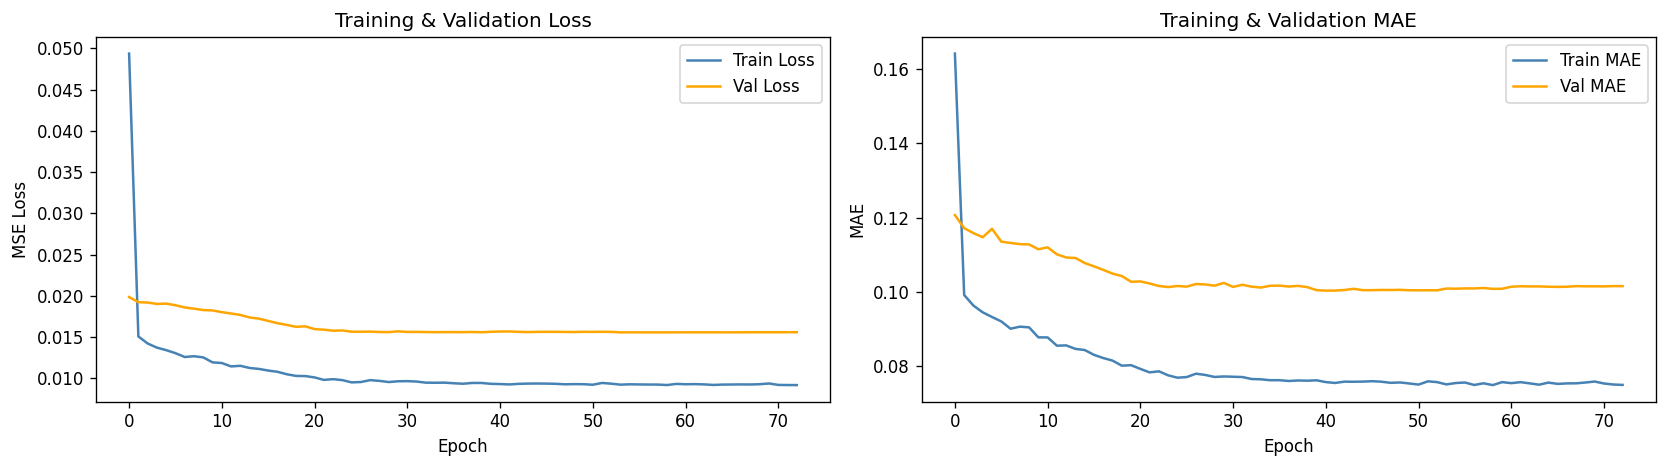

Best epoch: 58
Best val_loss: 0.015565


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(history.history["loss"], label="Train Loss", color="steelblue")
axes[0].plot(history.history["val_loss"], label="Val Loss", color="orange")
axes[0].set_title("Training & Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()

# MAE
axes[1].plot(history.history["mae"], label="Train MAE", color="steelblue")
axes[1].plot(history.history["val_mae"], label="Val MAE", color="orange")
axes[1].set_title("Training & Validation MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/10_lstm_training_history.png", dpi=150, bbox_inches="tight")
plt.show()

best_epoch = np.argmin(history.history["val_loss"]) + 1
print(f"Best epoch: {best_epoch}")
print(f"Best val_loss: {min(history.history['val_loss']):.6f}")

In [7]:
# Prediksi pada test set
y_pred_scaled = model.predict(X_test, verbose=0)

# Inverse transform ke skala asli (°C)
y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

def evaluate(actual, predicted, model_name="Model"):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    r2   = 1 - np.sum((actual - predicted)**2) / np.sum((actual - actual.mean())**2)

    print(f" Evaluasi {model_name} ")
    print(f"  MAE  : {mae:.3f}°C")
    print(f"  RMSE : {rmse:.3f}°C")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  R²   : {r2:.4f}")
    return {"model": model_name, "MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}

lstm_metrics = evaluate(y_true, y_pred, "LSTM")

 Evaluasi LSTM 
  MAE  : 0.490°C
  RMSE : 0.629°C
  MAPE : 1.70%
  R²   : 0.6487


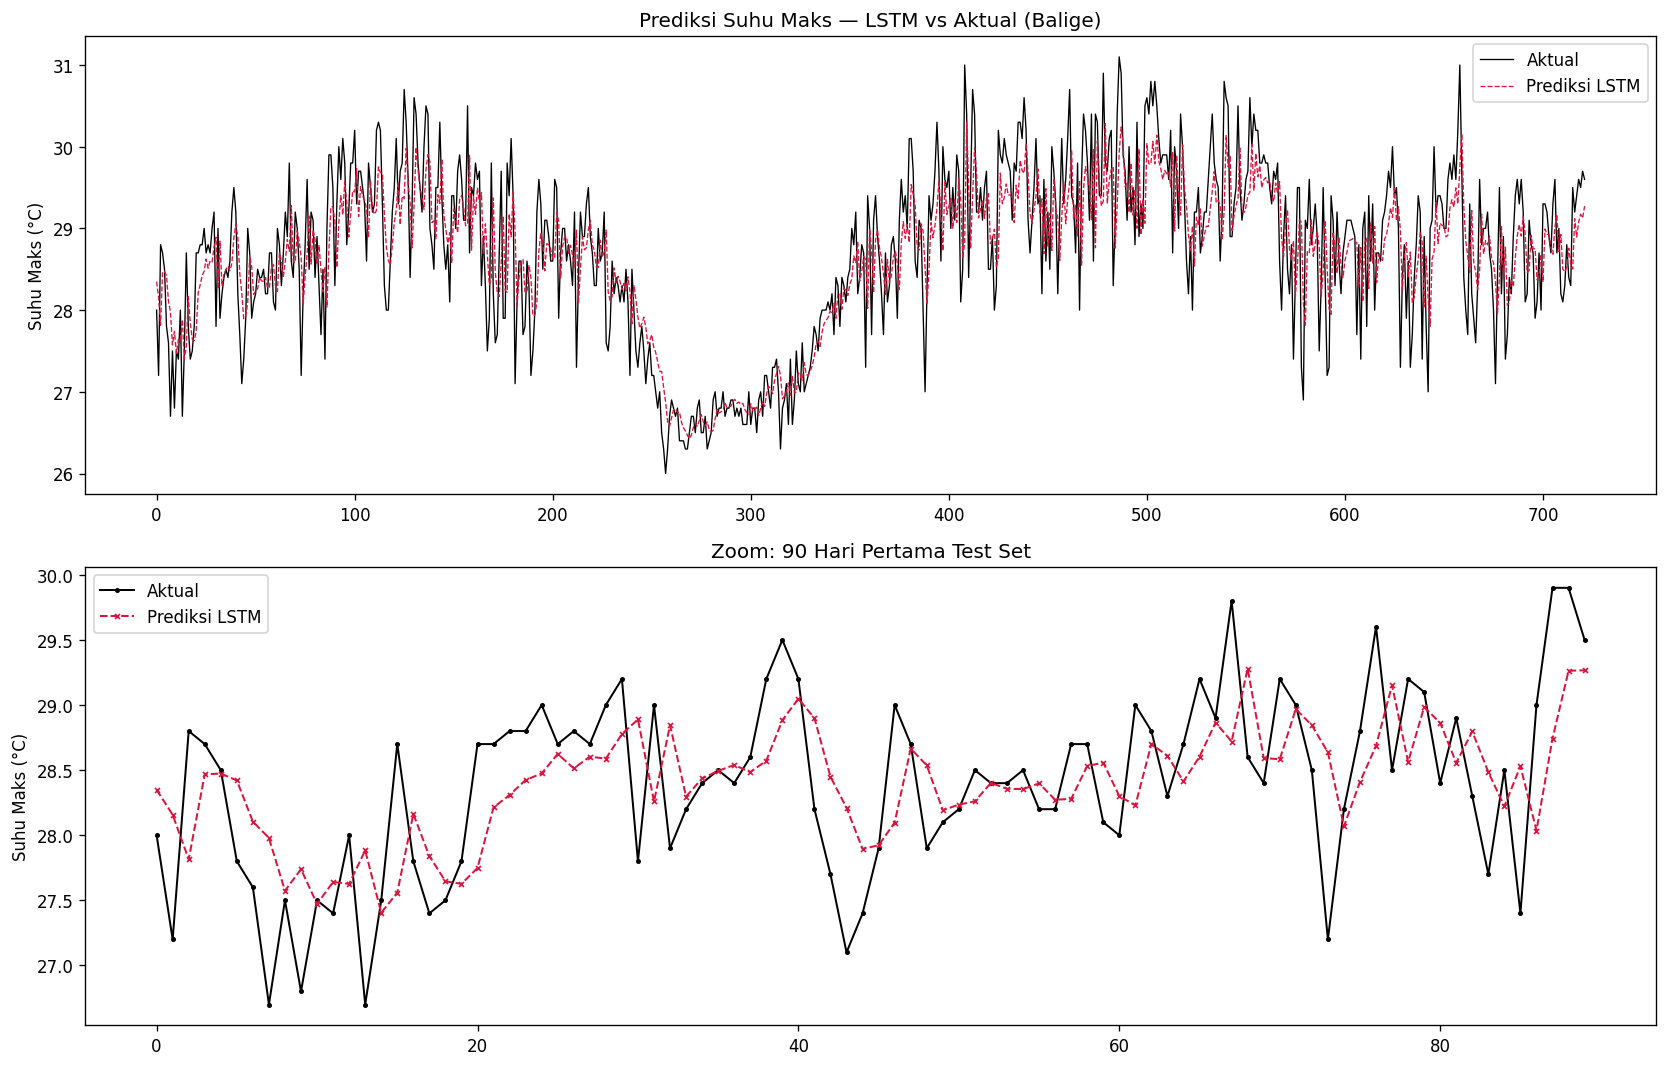

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Plot 1: full test set
axes[0].plot(y_true, color="black", linewidth=0.8, label="Aktual")
axes[0].plot(y_pred, color="crimson", linewidth=0.8,
             linestyle="--", label="Prediksi LSTM")
axes[0].set_title("Prediksi Suhu Maks — LSTM vs Aktual (Balige)")
axes[0].set_ylabel("Suhu Maks (°C)")
axes[0].legend()

# Plot 2: zoom 90 hari pertama
axes[1].plot(y_true[:90], color="black", linewidth=1.2,
             marker="o", markersize=2, label="Aktual")
axes[1].plot(y_pred[:90], color="crimson", linewidth=1.2,
             linestyle="--", marker="x", markersize=3, label="Prediksi LSTM")
axes[1].set_title("Zoom: 90 Hari Pertama Test Set")
axes[1].set_ylabel("Suhu Maks (°C)")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/11_lstm_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Simpan LSTM model & scaler
model.save("../models/lstm_model.keras")
with open("../models/lstm_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("Model & scaler disimpan")

# Update & tampilkan perbandingan final
metrics_path = "../models/metrics_comparison.json"
with open(metrics_path, "r") as f:
    metrics_data = json.load(f)

metrics_data["LSTM"] = lstm_metrics

with open(metrics_path, "w") as f:
    json.dump(metrics_data, f, indent=2)

# Tabel perbandingan final
print(f"   PERBANDINGAN FINAL: SARIMA vs Prophet vs LSTM")
print(f"{'Metrik':<8} {'SARIMA':>10} {'Prophet':>10} {'LSTM':>10} {'Winner':>10}")


sarima_m  = metrics_data["SARIMA"]
prophet_m = metrics_data["Prophet"]
lstm_m    = metrics_data["LSTM"]

for metric in ["MAE", "RMSE", "MAPE"]:
    vals   = {"SARIMA": sarima_m[metric], "Prophet": prophet_m[metric], "LSTM": lstm_m[metric]}
    winner = min(vals, key=vals.get)
    print(f"{metric:<8} {sarima_m[metric]:>10.3f} {prophet_m[metric]:>10.3f} "
          f"{lstm_m[metric]:>10.3f} {winner+' ':>10}")

vals_r2 = {"SARIMA": sarima_m["R2"], "Prophet": prophet_m["R2"], "LSTM": lstm_m["R2"]}
winner_r2 = max(vals_r2, key=vals_r2.get)
print(f"{'R²':<8} {sarima_m['R2']:>10.4f} {prophet_m['R2']:>10.4f} "
      f"{lstm_m['R2']:>10.4f} {winner_r2+' ✓':>10}")

print(f"{'='*55}")

# Tentukan model terbaik
best_model = min({"SARIMA": sarima_m["MAE"], "Prophet": prophet_m["MAE"],
                  "LSTM": lstm_m["MAE"]}, key=lambda k: {"SARIMA": sarima_m["MAE"],
                  "Prophet": prophet_m["MAE"], "LSTM": lstm_m["MAE"]}[k])
print(f"\n Model terbaik berdasarkan MAE: {best_model}")
print(f" Model ini yang akan di-deploy ke inference API")

Model & scaler disimpan!

   PERBANDINGAN FINAL: SARIMA vs Prophet vs LSTM
Metrik       SARIMA    Prophet       LSTM     Winner
-------------------------------------------------------
MAE           0.933      0.726      0.490     LSTM ✓
RMSE          1.112      0.884      0.629     LSTM ✓
MAPE          3.238      2.558      1.701     LSTM ✓
R²          -0.0978     0.3074     0.6487     LSTM ✓

 Model terbaik berdasarkan MAE: LSTM
    Model ini yang akan di-deploy ke inference API
